# Análisis espacial de exposición a CH4 y H2S
## Georreferenciación y análisis de distribución espacial

**Proyecto**: GAIA - Universidad Andina Simón Bolívar  
**Objetivo**: Convertir datos de sensores portátiles en información 
espacial, analizar la distribución geográfica de la exposición a gases 
de vertedero, y producir mapas para comunicación científica y comunitaria  
**Autor**: Luis Lascano  
**Fecha**: Mayo 2026  

### Contexto
Este notebook toma el dataset limpio de la Semana 1 y lo convierte 
en un GeoDataFrame para análisis espacial. Producimos mapas de exposición 
que relacionan la concentración de gases con la ubicación de trabajo 
de los recicladores respecto al Relleno de El Inga.

In [1]:
# Librerías para análisis espacial
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, box
import contextily as ctx
from pyproj import CRS

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns_style = {'axes.grid': True, 'grid.alpha': 0.3}
plt.rcParams.update(sns_style)

print("Librerías espaciales cargadas correctamente")

Librerías espaciales cargadas correctamente


In [2]:
# Cargar dataset limpio de la semana 1
df = pd.read_csv('../data/processed/sensor_data_clean.csv',
                 parse_dates=['timestamp'])

# Verificación rápida
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Período: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Recicladores: {df['reciclador_id'].nunique()}")
print(f"\nPrimeras 3 filas:")
df.head(3)

Dataset cargado: 7200 filas, 9 columnas
Período: 2026-05-01 08:00:00 → 2026-05-03 15:55:00
Recicladores: 25

Primeras 3 filas:


,timestamp,reciclador_id,dia,distancia_vertedero_m,lat,lon,CH4_ppm,H2S_ppb,temperatura_c
0,2026-05-01 08:00:00,REC_01,1,330.9,-0.380034,-78.314656,6.301,41.01,16.6
1,2026-05-01 08:05:00,REC_01,1,330.9,-0.383020,-78.319004,7.625,40.39,13.4
2,2026-05-01 08:10:00,REC_01,1,330.9,-0.386175,-78.316759,6.628,21.34,16.4


In [3]:
# Convertir DataFrame a GeoDataFrame
# Cada fila se convierte en un punto geográfico con sus coordenadas
geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]

gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Definir el sistema de referencia de coordenadas
# EPSG:4326 es WGS84, el sistema GPS estándar mundial
gdf = gdf.set_crs(epsg=4326)

# Verificación
print(f"Tipo de objeto: {type(gdf)}")
print(f"Sistema de referencia: {gdf.crs}")
print(f"\nColumna geometry:")
print(gdf['geometry'].head(3))

Tipo de objeto: <class 'geopandas.geodataframe.GeoDataFrame'>
Sistema de referencia: EPSG:4326

Columna geometry:
0    POINT (-78.31466 -0.38003)
1      POINT (-78.319 -0.38302)
2    POINT (-78.31676 -0.38618)
Name: geometry, dtype: geometry


In [4]:
# Coordenadas El Inga
lat_vertedero = -0.3833
lon_vertedero = -78.3167

# Crear punto del vertedero El Inga
vertedero = gpd.GeoDataFrame(
    {'nombre': ['Vertedero El Inga'],
     'tipo': ['Relleno sanitario activo']},
    geometry=[Point(lon_vertedero, lat_vertedero)],
    crs='EPSG:4326'
)

print("Ubicación del vertedero:")
print(vertedero[['nombre', 'geometry']])

Ubicación del vertedero:
              nombre                  geometry
0  Vertedero El Inga  POINT (-78.3167 -0.3833)


In [5]:
# Reproyectar a UTM zona 17S para Ecuador
# UTM permite calcular distancias en metros reales
gdf_utm = gdf.to_crs(epsg=32717)
vertedero_utm = vertedero.to_crs(epsg=32717)

print(f"CRS original: {gdf.crs}")
print(f"CRS reproyectado: {gdf_utm.crs}")
print(f"\nPunto original (grados):    {gdf['geometry'].iloc[0]}")
print(f"Punto reproyectado (metros): {gdf_utm['geometry'].iloc[0]}")

CRS original: EPSG:4326
CRS reproyectado: EPSG:32717

Punto original (grados):    POINT (-78.314656 -0.380034)
Punto reproyectado (metros): POINT (798915.2074428651 9957948.330971042)


In [6]:
# Calcular distancia de cada punto al vertedero
gdf_utm['distancia_calculada_m'] = gdf_utm.geometry.distance(
    vertedero_utm.geometry.iloc[0]
)

# Comparar distancia asiganda vs distancia calculada
print("=== COMPARACIÓN DE DISTANCIAS ===")
print(f"Distancia asignada promedio:  {gdf_utm['distancia_vertedero_m'].mean():.0f} m")
print(f"Distancia calculada promedio:      {gdf_utm['distancia_calculada_m'].mean():.0f} m")
print(f"\nDistancia calculada mínima:  {gdf_utm['distancia_calculada_m'].min():.0f} m")
print(f"Distancia calculada máxima:  {gdf_utm['distancia_calculada_m'].max():.0f} m")

# Agregar distancia calculada también al GeoDataFrame original
gdf['distancia_calculada_m'] = gdf_utm['distancia_calculada_m']

=== COMPARACIÓN DE DISTANCIAS ===
Distancia asignada promedio:  469 m
Distancia calculada promedio:      475 m

Distancia calculada mínima:  5 m
Distancia calculada máxima:  981 m


In [7]:
# Preparar datos para visualización
# Tomamos una muestra representativa para el mapa
# 7200 puntos superpuestos serían ilegibles
gdf_muestra = gdf.copy()

# Clasificar exposición CH4 en categorías
condiciones = [
    gdf_muestra['CH4_ppm'] <= 2.5,
    (gdf_muestra['CH4_ppm'] > 2.5) & (gdf_muestra['CH4_ppm'] <= 5.0),
    (gdf_muestra['CH4_ppm'] > 5.0) & (gdf_muestra['CH4_ppm'] <= 8.0),
    gdf_muestra['CH4_ppm'] > 8.0
]
categorias = ['Fondo (≤2.5)', 'Bajo (2.5-5)', 'Medio (5-8)', 'Alto (>8)']
colores_cat = ['green', 'yellow', 'orange', 'red']

gdf_muestra['categoria_ch4'] = np.select(condiciones, categorias, 
                                          default='Sin dato')

print("=== DISTRIBUCIÓN POR CATEGORÍA DE EXPOSICIÓN ===")
conteo = gdf_muestra['categoria_ch4'].value_counts()
for cat in categorias:
    if cat in conteo.index:
        pct = conteo[cat]/len(gdf_muestra)*100
        print(f"{cat}: {conteo[cat]} mediciones ({pct:.1f}%)")

=== DISTRIBUCIÓN POR CATEGORÍA DE EXPOSICIÓN ===
Fondo (≤2.5): 606 mediciones (8.4%)
Bajo (2.5-5): 2426 mediciones (33.7%)
Medio (5-8): 2302 mediciones (32.0%)
Alto (>8): 1666 mediciones (23.1%)


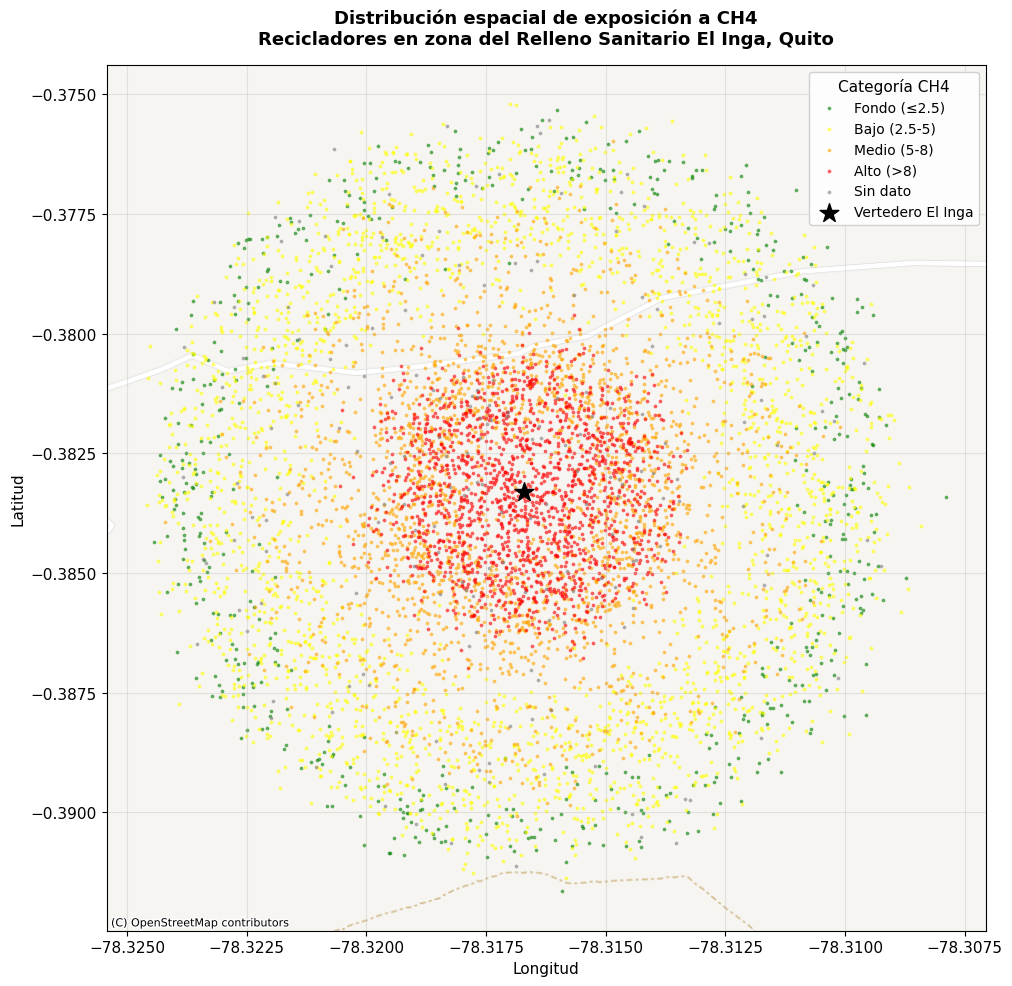

Mapa guardado en outputs/figures/


In [8]:
# Crear mapa de exposición por categoría
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Definir colores por categoría
color_map = {
    'Fondo (≤2.5)': 'green',
    'Bajo (2.5-5)': 'yellow',
    'Medio (5-8)': 'orange',
    'Alto (>8)': 'red',
    'Sin dato': 'gray'
}

# Graficar cada categoría por separado para control de colores
for categoria, color in color_map.items():
    subset = gdf_muestra[gdf_muestra['categoria_ch4'] == categoria]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=3, 
                   alpha=0.5, label=categoria)

# Agregar punto del vertedero
vertedero.plot(ax=ax, color='black', marker='*', 
               markersize=200, zorder=5, label='Vertedero El Inga')

# Agregar mapa base de OpenStreetMap
ctx.add_basemap(ax, crs=gdf.crs.to_string(),
                source=ctx.providers.OpenStreetMap.Mapnik,
                alpha=0.6)

# Configuración del mapa
ax.set_title('Distribución espacial de exposición a CH4\n'
             'Recicladores en zona del Relleno Sanitario El Inga, Quito',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Categoría CH4', loc='upper right', 
          framealpha=0.9, fontsize=10)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

plt.tight_layout()
plt.savefig('../outputs/figures/figura2_mapa_exposicion.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Mapa guardado en outputs/figures/")

In [9]:
# Eliminar columna duplicada que quedó de la versión anterior
if 'distancia_real_m' in gdf_muestra.columns:
    gdf_muestra = gdf_muestra.drop(columns=['distancia_real_m'])
    
# Exportar puntos de monitoreo a GeoJSON para QGIS
gdf_muestra.to_file('../data/processed/puntos_monitoreo.geojson', 
                     driver='GeoJSON')

# Exportar punto del vertedero
vertedero.to_file('../data/processed/vertedero_el_inga.geojson',
                  driver='GeoJSON')

print("Archivos exportados:")
print("✓ puntos_monitoreo.geojson")
print("✓ vertedero_el_inga.geojson")
print(f"\nCampos en puntos_monitoreo:")
print(gdf_muestra.columns.tolist())

Archivos exportados:
✓ puntos_monitoreo.geojson
✓ vertedero_el_inga.geojson

Campos en puntos_monitoreo:
['timestamp', 'reciclador_id', 'dia', 'distancia_vertedero_m', 'lat', 'lon', 'CH4_ppm', 'H2S_ppb', 'temperatura_c', 'geometry', 'distancia_calculada_m', 'categoria_ch4']


## Limitaciones metodológicas

### Representación del Relleno
El Relleno Sanitario El Inga se modela como un punto central de referencia.
En el estudio real se puede:
1. Usar el polígono oficial del área del relleno 
2. Calcular distancia al borde más cercano del polígono
3. Diferenciar zonas internas por tipo de actividad y perfil de emisión

Esta limitación afecta principalmente el análisis de distancia-exposición
para recicladores que trabajan dentro o en el borde inmediato del relleno.